# تمرین 3: کالبک‌ها در کراس — TensorBoard ،LR Finder ،توقف در دقت 75%
پیش‌نیاز: ویدیوهای آپارات که در صورت سوال داده شده + نوت‌بوک 06 هدی.


In [1]:
# فرض: model هدی یا هر مدل مشابه. اینجا یک مدل نمونه هدی/Fashion می‌سازیم تا کد مستقل اجرا شود
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
(x_tr,y_tr),(x_te,y_te)=keras.datasets.mnist.load_data()  # جایگزین سبک هدی؛ برای هدی همین کد با دیتای هدی کار می‌کند
x_tr=(x_tr.astype('float32')/255.0)[...,None]; x_te=(x_te.astype('float32')/255.0)[...,None]
y_tr=keras.utils.to_categorical(y_tr,10); y_te=keras.utils.to_categorical(y_te,10)
def make_hoda_like_model():
    m=keras.Sequential([layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),layers.MaxPooling2D((2,2)),layers.Conv2D(64,(3,3),activation='relu'),layers.MaxPooling2D((2,2)),layers.Flatten(),layers.Dropout(0.5),layers.Dense(128,activation='relu'),layers.Dense(10,activation='softmax')])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),loss='categorical_crossentropy',metrics=['accuracy'])
    return m


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## تمرین 3-1: فعال‌سازی TensorBoard + هیستوگرام لایه‌ها


In [2]:
# در Colab:
# %load_ext tensorboard
import datetime, os
log_dir = 'logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tensorboard_cb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True, write_images=True)
model = make_hoda_like_model()
model.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_data=(x_te,y_te), callbacks=[tensorboard_cb])
print('لاگ در:', log_dir)
print('در Colab اجرا کنید: %tensorboard --logdir logs/fit')
# از نمودار loss/accuracy و تب Histograms از لایه‌ها اسکرین‌شات بگیرید و همراه کد ارسال کنید.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9227 - loss: 0.2490 - val_accuracy: 0.9816 - val_loss: 0.0600
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9750 - loss: 0.0790 - val_accuracy: 0.9871 - val_loss: 0.0393
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9810 - loss: 0.0596 - val_accuracy: 0.9889 - val_loss: 0.0316
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9848 - loss: 0.0486 - val_accuracy: 0.9894 - val_loss: 0.0307
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9864 - loss: 0.0421 - val_accuracy: 0.9906 - val_loss: 0.0268
لاگ در: logs/fit/20261002-123550
در Colab اجرا کنید: %tensorboard --logdir logs/fit


## تمرین 3-2: پیدا کردن بهترین LR با کالبک مخصوص (LR Finder / LR Range Test)
ایده: از lr خیلی کوچک شروع کن، هر بچ نمایی زیادش کن، loss را رسم کن. بهترین lr جایی است که loss سریع نزولی است (حدود 1e-1 تا 1e-2 قبل از واگرایی).


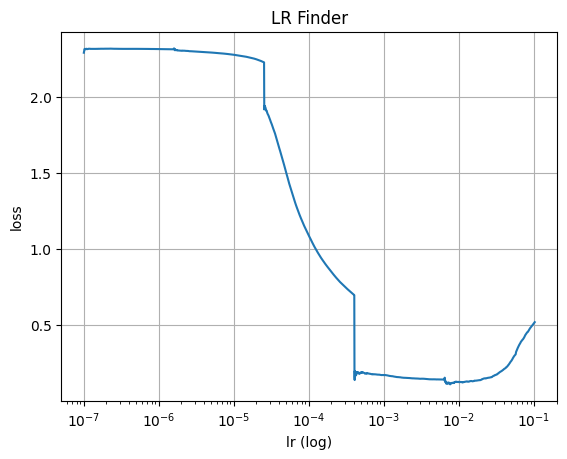

In [3]:
import matplotlib.pyplot as plt
import math
class LRFinder(keras.callbacks.Callback):
    def __init__(self, start_lr=1e-7, end_lr=1e-1, steps=None):
        super().__init__(); self.start_lr=start_lr; self.end_lr=end_lr; self.steps=steps
        self.lrs=[]; self.losses=[]
    def on_train_begin(self, logs=None):
        self.model.optimizer.learning_rate.assign(self.start_lr)
        self.mult = (self.end_lr/self.start_lr)**(1/self.steps) if self.steps else 1.02
    def on_train_batch_end(self, batch, logs=None):
        lr=float(self.model.optimizer.learning_rate.numpy())
        self.lrs.append(lr); self.losses.append(logs.get('loss'))
        self.model.optimizer.learning_rate.assign(lr*self.mult)
steps_per_epoch = len(x_tr)//128
STEPS = steps_per_epoch*5  # 5 اپوک برای جستجو کافی است
model2 = make_hoda_like_model()
finder = LRFinder(start_lr=1e-7, end_lr=1e-1, steps=STEPS)
model2.fit(x_tr, y_tr, epochs=5, batch_size=128, callbacks=[finder], verbose=0)
plt.semilogx(finder.lrs, finder.losses); plt.xlabel('lr (log)'); plt.ylabel('loss'); plt.title('LR Finder'); plt.grid(True); plt.show()
# قاعده: بهترین lr حدود 1/10 مینیمم منحنی است، مثلا اگر مینیمم ~1e-2 است، lr=1e-3 انتخاب کن.


## تمرین 3-3: توقف آموزش وقتی val_accuracy به 75% رسید


In [4]:
class StopAtAcc(keras.callbacks.Callback):
    def __init__(self, target=0.75):
        super().__init__(); self.target=target
    def on_epoch_end(self, epoch, logs=None):
        acc=(logs or {}).get('val_accuracy')
        if acc is not None and acc>=self.target:
            print(f'\nدقت ولیدیشن به {acc:.3f} رسید (>= {self.target}) — توقف آموزش در اپوک {epoch+1}')
            self.model.stop_training=True
model3 = make_hoda_like_model()
model3.fit(x_tr, y_tr, epochs=30, batch_size=128, validation_data=(x_te,y_te), callbacks=[StopAtAcc(0.75)], verbose=2)
# همین کالبک را می‌توانید روی نوت‌بوک 06 هدی هم بگذارید: callbacks=[StopAtAcc(0.75)]


Epoch 1/30

دقت ولیدیشن به 0.983 رسید (>= 0.75) — توقف آموزش در اپوک 1
469/469 - 8s - 16ms/step - accuracy: 0.9219 - loss: 0.2570 - val_accuracy: 0.9831 - val_loss: 0.0593
